<a href="https://colab.research.google.com/github/peachonali/Course-AI-and-Machine-Learning/blob/main/Week11_LAB7_Decision%20Tree%20ID3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. ให้นักศึกษาเขียนโปรแกรมภาษา Python เพื่อแก้ปัญหา 1D Linear Regression ด้วย Gradient Decent และแสดงผลการทำงานของโปรแกรมบนหน้าจอ ดังต่อไปนี้

In [ ]:
# -- Cell 1: Import & Dataset --------------------------------------

import math
import pandas as pd
from collections import Counter

# Play Tennis Dataset
data = [
    {"Day": "D1",  "Outlook": "Sunny",     "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "No"},
    {"Day": "D2",  "Outlook": "Sunny",     "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "No"},
    {"Day": "D3",  "Outlook": "Overcast",  "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D4",  "Outlook": "Rainy",      "Temperature": "Mild", "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "Yes"},
    {"Day": "D5",  "Outlook": "Rainy",      "Temperature": "Cool", "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D6",  "Outlook": "Rainy",      "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong", "PlayTennis": "No"},
    {"Day": "D7",  "Outlook": "Overcast",  "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong", "PlayTennis": "Yes"},
    {"Day": "D8",  "Outlook": "Sunny",     "Temperature": "Mild", "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "No"},
    {"Day": "D9",  "Outlook": "Sunny",     "Temperature": "Cool", "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D10", "Outlook": "Rainy",     "Temperature": "Mild", "Humidity":  "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D11", "Outlook": "Sunny",    "Temperature": "Mild", "Humidity":  "Normal", "Wind": "Strong", "PlayTennis": "Yes"},
    {"Day": "D12", "Outlook": "Overcast", "Temperature": "Mild", "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "Yes"},
    {"Day": "D13", "Outlook": "Overcast", "Temperature": "Hot",  "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D14", "Outlook": "Rainy",      "Temperature": "Mild", "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "No"}
]

df = pd.DataFrame(data)
TARGET = "PlayTennis"
FEATURES = ["Outlook", "Temperature", "Humidity", "Wind"]

print("=" * 60)
print(" ชุดข้อมูล Play Tennis (14 instances, 4 attributes)")
print("=" * 60)
print(df[["Day"] + FEATURES + [TARGET]].to_string(index=False))
print(f"\nClass distribution: {dict(Counter(df[TARGET]))}")

# -- Cell 2: Entropy & Information Gain Functions --------------------------------------

def entropy(labels):
    """
    คำนวณ Entropy ของ list ของ class labels
    H(S) = - Σ p_i *  log2(p_i)
    """
    n = len(labels)
    if n == 0:
        return 0.0
    counts = Counter(labels)
    h = 0.0
    for count in counts.values():
        p = count / n
        if p > 0:
            h -= p * math.log2(p)
    return h

def information_gain(df, attribute, target=TARGET):
    """
    คำนวณ Information Gain ของ attribute ที่กำหนด
    Gain(S, A) = H(S) - Σ (|Sv| / |S| ) * H(Sv)
    """
    h_parent = entropy(df[target])
    n            = len(df)

    # Calculate Weighted Entropy for each subset
    weighted_h = 0.0
    details = []
    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        h_subset = entropy(subset[target])
        weight = len(subset) / n
        weighted_h += weight * h_subset

        yes = sum(subset[target] == "Yes")
        no = sum(subset[target] == "No")
        details.append({
            "value": value,
            "n": len(subset),
            "yes": yes,
            "no": no,
            "H": round(h_subset, 4),
            "weight*H": round(weight * h_subset, 4),
        })

    gain = h_parent - weighted_h
    return round(gain, 4), round(h_parent, 4), round(weighted_h, 4), details

def best_attribute(df, attributes, target=TARGET):
    """เลือก attribute ที่ให้ Information Gain สูงสุด"""
    gains = {attr: information_gain(df, attr, target)[0] for attr in attributes}
    return max(gains, key=gains.get), gains

# -- Cell 3: Show calculating Gain for all Attribute on S --------------------------------------

print("\n" + "=" * 60)
print(" Step 1: คำนวณ Information Gain บน S ทั้งหมด" )
print("=" * 60)

h_s = entropy(df[TARGET])
yes_n = sum(df[TARGET] == "Yes")
no_n = sum(df[TARGET] == "No")
print(f"\nS = {len(df)} instances | Yes={yes_n}, No={no_n}")
print(f"H(S) = - ({yes_n}/14)*log2({yes_n}/14) - ({no_n}/14)*log2({no_n}/14)")
print(f"H(S) = {h_s:.4f} bits\n")

for attr in FEATURES:
    gain, h_p, h_cond, details = information_gain(df, attr)
    print(f"-- Attribute: {attr} --")
    header = f" {'Value' :<12} {'N':>4} {'Yes':>5} {'No':>5} {'H(Sv)':>8} {'wxH':>8}"
    print(header)
    print(" " + "-" * 50)
    for d in details:
        print(f"   {d['value'] :<12} {d['n']:>4} {d['yes']:>5} {d['no']:>5} "
              f"{d['H']:>8.4f} {d['weight*H']:>8.4f}")
    print(f" {' ' :>46} ------- ")
    print(f" H(S|{attr}) = {h_cond:.4f}")
    print(f" Gain(S, {attr}) = {h_p:.4f} - {h_cond:.4f} = {gain:.4f}\n")

best, gains = best_attribute(df, FEATURES)
print("=" * 60)
print(f" >> Root Node = '{best}' (Gain = {gains[best]:.4f})")
print("=" * 60)

# -- Cell 4: Create ID3 Decision Tree (Recursive) --------------------------------------

class DecisionNode:
    """Node for Decision Tree"""
    def __init__(self, attribute=None, label=None):
        self.attribute  = attribute            # internal node: attribute name
        self.label       = label                  # leaf node: class label
        self.children   = {}                     # {value: Decision Node}

    def is_leaf(self):
        return self.label is not None

def id3(df, attributes, target=TARGET, depth=0, parent_label=None, verbose=True):
    """
    สร้าง ID3 Decision Tree แบบ Recursive

    หยุดเมื่อ:
    1. ทุก instance ใน subset เป็น class เดียวกัน (pure + leaf)
    2. ไม่มี attribute เหลือให้แยก ( leaf ด้วย majority class)
    3. Subset ว่างเปล่า ( ใช้ majority class ของ parent)
    """
    indent = "  " * depth

    # Case: subset is NULL
    if len(df) == 0:
        return DecisionNode(label=parent_label)

    # Count current class
    class_counts = Counter(df[target])
    majority = class_counts.most_common(1)[0][0]

    # Case #1: Pure node
    if len(class_counts) == 1:
        label = list(class_counts.keys())[0]
        if verbose:
            print(f"{indent}[Leaf] -> '{label}' "
                  f"(pure: {dict(class_counts)}, H=0.0000)")
        return DecisionNode(label=label)

    # Case #2: No more attribute
    if not attributes:
        if verbose:
            print(f"{indent}[Leaf] -> '{majority}' "
                  f"(majority: {dict(class_counts)})")
        return DecisionNode(label=majority)

    # Choose the best attribute
    best_attr, gains = best_attribute(df, attributes, target)
    h_current = entropy(df[target])

    if verbose:
        yes = class_counts.get("Yes", 0)
        no = class_counts.get("No", 0)
        print(f"{indent}[Node] S={len(df)} (Yes={yes}, No={no}) "
              f"H={h_current:.4f}")
        for a in sorted(gains, key=gains.get, reverse=True):
            marker = " <- best" if a == best_attr else ""
            print(f"{indent}          Gain({a}) = {gains[a]:.4f}{marker}")
        print(f"{indent} Split on: '{best_attr}' ")

    node                = DecisionNode(attribute=best_attr)
    remaining_attrs = [a for a in attributes if a != best_attr]

    for value in sorted(df[best_attr].unique()):
        subset = df[df[best_attr] == value]
        if verbose:
            y = sum(subset[target] == "Yes")
            n = sum(subset[target] == "No")
            print(f"{indent}  {best_attr}='{value}' "
                  f"-> subset={len(subset)} (Yes={y}, No={n})")
        child = id3(subset, remaining_attrs, target,
                    depth + 2, majority, verbose)
        node.children[value] = child

    return node

print("\n" + "=" * 60)
print(" Step 2-4: สร้าง ID3 Tree (verbose log)")
print("=" * 60 + "\n")

tree = id3(df.copy(), FEATURES.copy(), TARGET, depth=0, verbose=True)

# -- Cell 5: Show Tree in Text --------------------------------------

def print_tree(node, feature_value="ROOT", depth=0):
    """แสดง Decision Tree ในรูปแบบ text"""
    indent = "  " * depth
    if node.is_leaf():
        print(f"{indent}[{feature_value}] -> Predict: '{node.label}' ")
    else:
        print(f"{indent}[{feature_value}] -> Test: '{node.attribute}' ")
        for value, child in sorted(node.children.items()):
            print_tree(child, value, depth + 1)

print("\n" + "=" * 60)
print(" Decision Tree Structure")
print("=" * 60)
print_tree(tree)

# -- Cell 6: Predict --------------------------------------

def predict(node, instance):
    """Classify instance by Decision Tree"""
    if node.is_leaf():
        return node.label
    value = instance.get(node.attribute)
    if value not in node.children:
        # In case not seen in training
        return None
    return predict(node.children[value], instance)

# Test on all training data
print("\n" + "=" * 60)
print("  Prediction on Training Data")
print("=" * 60)

correct = 0
rows = []
for _, row in df.iterrows():
    instance      = row[FEATURES].to_dict()
    actual         = row[TARGET]
    predicted    = predict(tree, instance)
    ok              = predicted == actual
    if ok:
        correct += 1
    rows.append({
        "Day": row["Day"],
        "Outlook": row["Outlook"],
        "Temperature": row["Temperature"],
        "Humidity": row["Humidity"],
        "Wind": row["Wind"],
        "Actual": actual,
        "Predicted": predicted,
        "Correct": "✔" if ok else "✘",
    })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))
print(f"\nAccuracy = {correct}/{len(df)} = {correct/len(df)*100:.1f}%")

 ชุดข้อมูล Play Tennis (14 instances, 4 attributes)
Day  Outlook Temperature Humidity   Wind PlayTennis
 D1    Sunny         Hot     High   Weak         No
 D2    Sunny         Hot     High Strong         No
 D3 Overcast         Hot     High   Weak        Yes
 D4    Rainy        Mild     High   Weak        Yes
 D5    Rainy        Cool   Normal   Weak        Yes
 D6    Rainy        Cool   Normal Strong         No
 D7 Overcast        Cool   Normal Strong        Yes
 D8    Sunny        Mild     High   Weak         No
 D9    Sunny        Cool   Normal   Weak        Yes
D10    Rainy        Mild   Normal   Weak        Yes
D11    Sunny        Mild   Normal Strong        Yes
D12 Overcast        Mild     High Strong        Yes
D13 Overcast         Hot   Normal   Weak        Yes
D14    Rainy        Mild     High Strong         No

Class distribution: {'No': 5, 'Yes': 9}

 Step 1: คำนวณ Information Gain บน S ทั้งหมด

S = 14 instances | Yes=9, No=5
H(S) = - (9/14)*log2(9/14) - (5/14)*log2(5/14)
H(

# 2. จากโปรแกรมในข้อ 1 ให้ นศ ปรับปรุงโปรแกรมดังกล่าวให้สร้างชุดข้อมูลสำหรับการทดสอบดังนี้
test_cases = [


{"Outlook": "Sunny",    "Temperature": "Hot",  "Humidity": "High",   "Wind": "Weak"},


{"Outlook": "Rainy",    "Temperature": "Mild", "Humidity": "Normal", "Wind": "Strong"},


{"Outlook": "Overcast", "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong"},]


จากนั้นให้โปรแกรมทำนายค่าผลลัพธ์ที่ได้จากการใช้ Decision Tree ที่สร้างขึ้นมาจากข้อ 1


In [ ]:
# -- Cell 1: Import & Dataset --------------------------------------

import math
import pandas as pd
from collections import Counter

# Play Tennis Dataset
data = [
    {"Day": "D1",  "Outlook": "Sunny",     "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "No"},
    {"Day": "D2",  "Outlook": "Sunny",     "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "No"},
    {"Day": "D3",  "Outlook": "Overcast",  "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D4",  "Outlook": "Rainy",      "Temperature": "Mild", "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "Yes"},
    {"Day": "D5",  "Outlook": "Rainy",      "Temperature": "Cool", "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D6",  "Outlook": "Rainy",      "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong", "PlayTennis": "No"},
    {"Day": "D7",  "Outlook": "Overcast",  "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong", "PlayTennis": "Yes"},
    {"Day": "D8",  "Outlook": "Sunny",     "Temperature": "Mild", "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "No"},
    {"Day": "D9",  "Outlook": "Sunny",     "Temperature": "Cool", "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D10", "Outlook": "Rainy",     "Temperature": "Mild", "Humidity":  "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D11", "Outlook": "Sunny",    "Temperature": "Mild", "Humidity":  "Normal", "Wind": "Strong", "PlayTennis": "Yes"},
    {"Day": "D12", "Outlook": "Overcast", "Temperature": "Mild", "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "Yes"},
    {"Day": "D13", "Outlook": "Overcast", "Temperature": "Hot",  "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D14", "Outlook": "Rainy",      "Temperature": "Mild", "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "No"}
]

df = pd.DataFrame(data)
TARGET = "PlayTennis"
FEATURES = ["Outlook", "Temperature", "Humidity", "Wind"]

print("=" * 60)
print(" ชุดข้อมูล Play Tennis (14 instances, 4 attributes)")
print("=" * 60)
print(df[["Day"] + FEATURES + [TARGET]].to_string(index=False))
print(f"\nClass distribution: {dict(Counter(df[TARGET]))}")

# -- Cell 2: Entropy & Information Gain Functions --------------------------------------

def entropy(labels):
    """
    คำนวณ Entropy ของ list ของ class labels
    H(S) = - Σ p_i *  log2(p_i)
    """
    n = len(labels)
    if n == 0:
        return 0.0
    counts = Counter(labels)
    h = 0.0
    for count in counts.values():
        p = count / n
        if p > 0:
            h -= p * math.log2(p)
    return h

def information_gain(df, attribute, target=TARGET):
    """
    คำนวณ Information Gain ของ attribute ที่กำหนด
    Gain(S, A) = H(S) - Σ (|Sv| / |S| ) * H(Sv)
    """
    h_parent = entropy(df[target])
    n            = len(df)

    # Calculate Weighted Entropy for each subset
    weighted_h = 0.0
    details = []
    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        h_subset = entropy(subset[target])
        weight = len(subset) / n
        weighted_h += weight * h_subset

        yes = sum(subset[target] == "Yes")
        no = sum(subset[target] == "No")
        details.append({
            "value": value,
            "n": len(subset),
            "yes": yes,
            "no": no,
            "H": round(h_subset, 4),
            "weight*H": round(weight * h_subset, 4),
        })

    gain = h_parent - weighted_h
    return round(gain, 4), round(h_parent, 4), round(weighted_h, 4), details

def best_attribute(df, attributes, target=TARGET):
    """เลือก attribute ที่ให้ Information Gain สูงสุด"""
    gains = {attr: information_gain(df, attr, target)[0] for attr in attributes}
    return max(gains, key=gains.get), gains

# -- Cell 3: Show calculating Gain for all Attribute on S --------------------------------------

print("\n" + "=" * 60)
print(" Step 1: คำนวณ Information Gain บน S ทั้งหมด" )
print("=" * 60)

h_s = entropy(df[TARGET])
yes_n = sum(df[TARGET] == "Yes")
no_n = sum(df[TARGET] == "No")
print(f"\nS = {len(df)} instances | Yes={yes_n}, No={no_n}")
print(f"H(S) = - ({yes_n}/14)*log2({yes_n}/14) - ({no_n}/14)*log2({no_n}/14)")
print(f"H(S) = {h_s:.4f} bits\n")

for attr in FEATURES:
    gain, h_p, h_cond, details = information_gain(df, attr)
    print(f"-- Attribute: {attr} --")
    header = f" {'Value' :<12} {'N':>4} {'Yes':>5} {'No':>5} {'H(Sv)':>8} {'wxH':>8}"
    print(header)
    print(" " + "-" * 50)
    for d in details:
        print(f"   {d['value'] :<12} {d['n']:>4} {d['yes']:>5} {d['no']:>5} "
              f"{d['H']:>8.4f} {d['weight*H']:>8.4f}")
    print(f" {' ' :>46} ------- ")
    print(f" H(S|{attr}) = {h_cond:.4f}")
    print(f" Gain(S, {attr}) = {h_p:.4f} - {h_cond:.4f} = {gain:.4f}\n")

best, gains = best_attribute(df, FEATURES)
print("=" * 60)
print(f" >> Root Node = '{best}' (Gain = {gains[best]:.4f})")
print("=" * 60)

# -- Cell 4: Create ID3 Decision Tree (Recursive) --------------------------------------

class DecisionNode:
    """Node for Decision Tree"""
    def __init__(self, attribute=None, label=None):
        self.attribute  = attribute            # internal node: attribute name
        self.label       = label                  # leaf node: class label
        self.children   = {}                     # {value: Decision Node}

    def is_leaf(self):
        return self.label is not None

def id3(df, attributes, target=TARGET, depth=0, parent_label=None, verbose=True):
    """
    สร้าง ID3 Decision Tree แบบ Recursive

    หยุดเมื่อ:
    1. ทุก instance ใน subset เป็น class เดียวกัน (pure + leaf)
    2. ไม่มี attribute เหลือให้แยก ( leaf ด้วย majority class)
    3. Subset ว่างเปล่า ( ใช้ majority class ของ parent)
    """
    indent = "  " * depth

    # Case: subset is NULL
    if len(df) == 0:
        return DecisionNode(label=parent_label)

    # Count current class
    class_counts = Counter(df[target])
    majority = class_counts.most_common(1)[0][0]

    # Case #1: Pure node
    if len(class_counts) == 1:
        label = list(class_counts.keys())[0]
        if verbose:
            print(f"{indent}[Leaf] -> '{label}' "
                  f"(pure: {dict(class_counts)}, H=0.0000)")
        return DecisionNode(label=label)

    # Case #2: No more attribute
    if not attributes:
        if verbose:
            print(f"{indent}[Leaf] -> '{majority}' "
                  f"(majority: {dict(class_counts)})")
        return DecisionNode(label=majority)

    # Choose the best attribute
    best_attr, gains = best_attribute(df, attributes, target)
    h_current = entropy(df[target])

    if verbose:
        yes = class_counts.get("Yes", 0)
        no = class_counts.get("No", 0)
        print(f"{indent}[Node] S={len(df)} (Yes={yes}, No={no}) "
              f"H={h_current:.4f}")
        for a in sorted(gains, key=gains.get, reverse=True):
            marker = " <- best" if a == best_attr else ""
            print(f"{indent}          Gain({a}) = {gains[a]:.4f}{marker}")
        print(f"{indent} Split on: '{best_attr}' ")

    node                = DecisionNode(attribute=best_attr)
    remaining_attrs = [a for a in attributes if a != best_attr]

    for value in sorted(df[best_attr].unique()):
        subset = df[df[best_attr] == value]
        if verbose:
            y = sum(subset[target] == "Yes")
            n = sum(subset[target] == "No")
            print(f"{indent}  {best_attr}='{value}' "
                  f"-> subset={len(subset)} (Yes={y}, No={n})")
        child = id3(subset, remaining_attrs, target,
                    depth + 2, majority, verbose)
        node.children[value] = child

    return node

print("\n" + "=" * 60)
print(" Step 2-4: สร้าง ID3 Tree (verbose log)")
print("=" * 60 + "\n")

tree = id3(df.copy(), FEATURES.copy(), TARGET, depth=0, verbose=True)

# -- Cell 5: Show Tree in Text --------------------------------------

def print_tree(node, feature_value="ROOT", depth=0):
    """แสดง Decision Tree ในรูปแบบ text"""
    indent = "  " * depth
    if node.is_leaf():
        print(f"{indent}[{feature_value}] -> Predict: '{node.label}' ")
    else:
        print(f"{indent}[{feature_value}] -> Test: '{node.attribute}' ")
        for value, child in sorted(node.children.items()):
            print_tree(child, value, depth + 1)

print("\n" + "=" * 60)
print(" Decision Tree Structure")
print("=" * 60)
print_tree(tree)

# -- Cell 6: Predict --------------------------------------

def predict(node, instance):
    """Classify instance by Decision Tree"""
    if node.is_leaf():
        return node.label
    value = instance.get(node.attribute)
    if value not in node.children:
        # In case not seen in training
        return None
    return predict(node.children[value], instance)

# Test on all training data
print("\n" + "=" * 60)
print("  Prediction on Training Data")
print("=" * 60)

correct = 0
rows = []
for _, row in df.iterrows():
    instance      = row[FEATURES].to_dict()
    actual         = row[TARGET]
    predicted    = predict(tree, instance)
    ok              = predicted == actual
    if ok:
        correct += 1
    rows.append({
        "Day": row["Day"],
        "Outlook": row["Outlook"],
        "Temperature": row["Temperature"],
        "Humidity": row["Humidity"],
        "Wind": row["Wind"],
        "Actual": actual,
        "Predicted": predicted,
        "Correct": "✔" if ok else "✘",
    })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))
print(f"\nAccuracy = {correct}/{len(df)} = {correct/len(df)*100:.1f}%")


# เพิ่มเติมส่วนนี้จากข้อ 2 -----------------------------------------------------
# -- Cell 7: Test Cases & Prediction --------------------------------------

test_cases = [
    {"Outlook": "Sunny",    "Temperature": "Hot",  "Humidity": "High",   "Wind": "Weak"},
    {"Outlook": "Rainy",    "Temperature": "Mild", "Humidity": "Normal", "Wind": "Strong"},
    {"Outlook": "Overcast", "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong"}
]

print("\n" + "=" * 60)
print("  Prediction on Test Cases")
print("=" * 60)

test_results = []
for i, instance in enumerate(test_cases):
    predicted = predict(tree, instance)
    test_results.append({
        "Test Case": f"Case {i+1}",
        **instance, # Unpack dictionary
        "Predicted": predicted
    })

test_df = pd.DataFrame(test_results)
print(test_df.to_string(index=False))

 ชุดข้อมูล Play Tennis (14 instances, 4 attributes)
Day  Outlook Temperature Humidity   Wind PlayTennis
 D1    Sunny         Hot     High   Weak         No
 D2    Sunny         Hot     High Strong         No
 D3 Overcast         Hot     High   Weak        Yes
 D4    Rainy        Mild     High   Weak        Yes
 D5    Rainy        Cool   Normal   Weak        Yes
 D6    Rainy        Cool   Normal Strong         No
 D7 Overcast        Cool   Normal Strong        Yes
 D8    Sunny        Mild     High   Weak         No
 D9    Sunny        Cool   Normal   Weak        Yes
D10    Rainy        Mild   Normal   Weak        Yes
D11    Sunny        Mild   Normal Strong        Yes
D12 Overcast        Mild     High Strong        Yes
D13 Overcast         Hot   Normal   Weak        Yes
D14    Rainy        Mild     High Strong         No

Class distribution: {'No': 5, 'Yes': 9}

 Step 1: คำนวณ Information Gain บน S ทั้งหมด

S = 14 instances | Yes=9, No=5
H(S) = - (9/14)*log2(9/14) - (5/14)*log2(5/14)
H(

#ข้อ 3 ให้นักศึกษาเขียนโปรแกรมใหม่โดยใช้ Library สำเร็จรูปจาก Scikit Learn เพื่อสร้าง Decision Tree จากชุดข้อมูล Play Tennis Dataset โดยใช้อัลกอริทึม CART และทำการเปรียบเทียบโครงสร้างของ Decision Tree ที่ได้จากอัลกอริทึม CART กับโครงสร้างของ Decision Tree จากอัลกอริทึม ID3 ในข้อ 1 ว่ามีความเหมือนหรือแตกต่างกันอย่างไร

In [ ]:
# -- Cell 1: Import & Dataset --------------------------------------

import math
import pandas as pd
from collections import Counter

# Play Tennis Dataset
data = [
    {"Day": "D1",  "Outlook": "Sunny",     "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "No"},
    {"Day": "D2",  "Outlook": "Sunny",     "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "No"},
    {"Day": "D3",  "Outlook": "Overcast",  "Temperature": "Hot",  "Humidity":  "High",   "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D4",  "Outlook": "Rainy",      "Temperature": "Mild", "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "Yes"},
    {"Day": "D5",  "Outlook": "Rainy",      "Temperature": "Cool", "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D6",  "Outlook": "Rainy",      "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong", "PlayTennis": "No"},
    {"Day": "D7",  "Outlook": "Overcast",  "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong", "PlayTennis": "Yes"},
    {"Day": "D8",  "Outlook": "Sunny",     "Temperature": "Mild", "Humidity":  "High",   "Wind": "Weak",   "PlayTennis":  "No"},
    {"Day": "D9",  "Outlook": "Sunny",     "Temperature": "Cool", "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D10", "Outlook": "Rainy",     "Temperature": "Mild", "Humidity":  "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D11", "Outlook": "Sunny",    "Temperature": "Mild", "Humidity":  "Normal", "Wind": "Strong", "PlayTennis": "Yes"},
    {"Day": "D12", "Outlook": "Overcast", "Temperature": "Mild", "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "Yes"},
    {"Day": "D13", "Outlook": "Overcast", "Temperature": "Hot",  "Humidity": "Normal", "Wind": "Weak",   "PlayTennis": "Yes"},
    {"Day": "D14", "Outlook": "Rainy",      "Temperature": "Mild", "Humidity":  "High",   "Wind": "Strong", "PlayTennis":  "No"}
]

df = pd.DataFrame(data)
TARGET = "PlayTennis"
FEATURES = ["Outlook", "Temperature", "Humidity", "Wind"]

print("=" * 60)
print(" ชุดข้อมูล Play Tennis (14 instances, 4 attributes)")
print("=" * 60)
print(df[["Day"] + FEATURES + [TARGET]].to_string(index=False))
print(f"\nClass distribution: {dict(Counter(df[TARGET]))}")

# -- Cell 2: Entropy & Information Gain Functions --------------------------------------

def entropy(labels):
    """
    คำนวณ Entropy ของ list ของ class labels
    H(S) = - Σ p_i *  log2(p_i)
    """
    n = len(labels)
    if n == 0:
        return 0.0
    counts = Counter(labels)
    h = 0.0
    for count in counts.values():
        p = count / n
        if p > 0:
            h -= p * math.log2(p)
    return h

def information_gain(df, attribute, target=TARGET):
    """
    คำนวณ Information Gain ของ attribute ที่กำหนด
    Gain(S, A) = H(S) - Σ (|Sv| / |S| ) * H(Sv)
    """
    h_parent = entropy(df[target])
    n            = len(df)

    # Calculate Weighted Entropy for each subset
    weighted_h = 0.0
    details = []
    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        h_subset = entropy(subset[target])
        weight = len(subset) / n
        weighted_h += weight * h_subset

        yes = sum(subset[target] == "Yes")
        no = sum(subset[target] == "No")
        details.append({
            "value": value,
            "n": len(subset),
            "yes": yes,
            "no": no,
            "H": round(h_subset, 4),
            "weight*H": round(weight * h_subset, 4),
        })

    gain = h_parent - weighted_h
    return round(gain, 4), round(h_parent, 4), round(weighted_h, 4), details

def best_attribute(df, attributes, target=TARGET):
    """เลือก attribute ที่ให้ Information Gain สูงสุด"""
    gains = {attr: information_gain(df, attr, target)[0] for attr in attributes}
    return max(gains, key=gains.get), gains

# -- Cell 3: Show calculating Gain for all Attribute on S --------------------------------------

print("\n" + "=" * 60)
print(" Step 1: คำนวณ Information Gain บน S ทั้งหมด" )
print("=" * 60)

h_s = entropy(df[TARGET])
yes_n = sum(df[TARGET] == "Yes")
no_n = sum(df[TARGET] == "No")
print(f"\nS = {len(df)} instances | Yes={yes_n}, No={no_n}")
print(f"H(S) = - ({yes_n}/14)*log2({yes_n}/14) - ({no_n}/14)*log2({no_n}/14)")
print(f"H(S) = {h_s:.4f} bits\n")

for attr in FEATURES:
    gain, h_p, h_cond, details = information_gain(df, attr)
    print(f"-- Attribute: {attr} --")
    header = f" {'Value' :<12} {'N':>4} {'Yes':>5} {'No':>5} {'H(Sv)':>8} {'wxH':>8}"
    print(header)
    print(" " + "-" * 50)
    for d in details:
        print(f"   {d['value'] :<12} {d['n']:>4} {d['yes']:>5} {d['no']:>5} "
              f"{d['H']:>8.4f} {d['weight*H']:>8.4f}")
    print(f" {' ' :>46} ------- ")
    print(f" H(S|{attr}) = {h_cond:.4f}")
    print(f" Gain(S, {attr}) = {h_p:.4f} - {h_cond:.4f} = {gain:.4f}\n")

best, gains = best_attribute(df, FEATURES)
print("=" * 60)
print(f" >> Root Node = '{best}' (Gain = {gains[best]:.4f})")
print("=" * 60)

# -- Cell 4: Create ID3 Decision Tree (Recursive) --------------------------------------

class DecisionNode:
    """Node for Decision Tree"""
    def __init__(self, attribute=None, label=None):
        self.attribute  = attribute            # internal node: attribute name
        self.label       = label                  # leaf node: class label
        self.children   = {}                     # {value: Decision Node}

    def is_leaf(self):
        return self.label is not None

def id3(df, attributes, target=TARGET, depth=0, parent_label=None, verbose=True):
    """
    สร้าง ID3 Decision Tree แบบ Recursive

    หยุดเมื่อ:
    1. ทุก instance ใน subset เป็น class เดียวกัน (pure + leaf)
    2. ไม่มี attribute เหลือให้แยก ( leaf ด้วย majority class)
    3. Subset ว่างเปล่า ( ใช้ majority class ของ parent)
    """
    indent = "  " * depth

    # Case: subset is NULL
    if len(df) == 0:
        return DecisionNode(label=parent_label)

    # Count current class
    class_counts = Counter(df[target])
    majority = class_counts.most_common(1)[0][0]

    # Case #1: Pure node
    if len(class_counts) == 1:
        label = list(class_counts.keys())[0]
        if verbose:
            print(f"{indent}[Leaf] -> '{label}' "
                  f"(pure: {dict(class_counts)}, H=0.0000)")
        return DecisionNode(label=label)

    # Case #2: No more attribute
    if not attributes:
        if verbose:
            print(f"{indent}[Leaf] -> '{majority}' "
                  f"(majority: {dict(class_counts)})")
        return DecisionNode(label=majority)

    # Choose the best attribute
    best_attr, gains = best_attribute(df, attributes, target)
    h_current = entropy(df[target])

    if verbose:
        yes = class_counts.get("Yes", 0)
        no = class_counts.get("No", 0)
        print(f"{indent}[Node] S={len(df)} (Yes={yes}, No={no}) "
              f"H={h_current:.4f}")
        for a in sorted(gains, key=gains.get, reverse=True):
            marker = " <- best" if a == best_attr else ""
            print(f"{indent}          Gain({a}) = {gains[a]:.4f}{marker}")
        print(f"{indent} Split on: '{best_attr}' ")

    node                = DecisionNode(attribute=best_attr)
    remaining_attrs = [a for a in attributes if a != best_attr]

    for value in sorted(df[best_attr].unique()):
        subset = df[df[best_attr] == value]
        if verbose:
            y = sum(subset[target] == "Yes")
            n = sum(subset[target] == "No")
            print(f"{indent}  {best_attr}='{value}' "
                  f"-> subset={len(subset)} (Yes={y}, No={n})")
        child = id3(subset, remaining_attrs, target,
                    depth + 2, majority, verbose)
        node.children[value] = child

    return node

print("\n" + "=" * 60)
print(" Step 2-4: สร้าง ID3 Tree (verbose log)")
print("=" * 60 + "\n")

tree = id3(df.copy(), FEATURES.copy(), TARGET, depth=0, verbose=True)

# -- Cell 5: Show Tree in Text --------------------------------------

def print_tree(node, feature_value="ROOT", depth=0):
    """แสดง Decision Tree ในรูปแบบ text"""
    indent = "  " * depth
    if node.is_leaf():
        print(f"{indent}[{feature_value}] -> Predict: '{node.label}' ")
    else:
        print(f"{indent}[{feature_value}] -> Test: '{node.attribute}' ")
        for value, child in sorted(node.children.items()):
            print_tree(child, value, depth + 1)

print("\n" + "=" * 60)
print(" Decision Tree Structure")
print("=" * 60)
print_tree(tree)

# -- Cell 6: Predict --------------------------------------

def predict(node, instance):
    """Classify instance by Decision Tree"""
    if node.is_leaf():
        return node.label
    value = instance.get(node.attribute)
    if value not in node.children:
        # In case not seen in training
        return None
    return predict(node.children[value], instance)

# Test on all training data
print("\n" + "=" * 60)
print("  Prediction on Training Data")
print("=" * 60)

correct = 0
rows = []
for _, row in df.iterrows():
    instance      = row[FEATURES].to_dict()
    actual         = row[TARGET]
    predicted    = predict(tree, instance)
    ok              = predicted == actual
    if ok:
        correct += 1
    rows.append({
        "Day": row["Day"],
        "Outlook": row["Outlook"],
        "Temperature": row["Temperature"],
        "Humidity": row["Humidity"],
        "Wind": row["Wind"],
        "Actual": actual,
        "Predicted": predicted,
        "Correct": "✔" if ok else "✘",
    })

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))
print(f"\nAccuracy = {correct}/{len(df)} = {correct/len(df)*100:.1f}%")

# -- Cell 7: CART Decision Tree (Scikit-learn) ----------------------------

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_cart = df.copy()

# Encode categorical features → numeric
encoders = {}
for col in FEATURES:
    le = LabelEncoder()
    df_cart[col] = le.fit_transform(df_cart[col])
    encoders[col] = le

# Encode target
target_encoder = LabelEncoder()
df_cart[TARGET] = target_encoder.fit_transform(df_cart[TARGET])

X = df_cart[FEATURES]
y = df_cart[TARGET]

# Train CART (Gini index by default)
cart_model = DecisionTreeClassifier(criterion="gini", random_state=42)
cart_model.fit(X, y)

# Show tree structure
print("\n" + "=" * 60)
print(" CART Decision Tree Structure (Scikit-learn)")
print("=" * 60)

tree_rules = export_text(cart_model, feature_names=FEATURES)
print(tree_rules)

# -- Cell 8: Predict with CART --------------------------------------

print("\n" + "=" * 60)
print("  CART Prediction on Training Data")
print("=" * 60)

correct = 0
rows = []

for _, row in df.iterrows():
    instance = row[FEATURES].to_dict()

    encoded_instance = {}
    for col in FEATURES:
        encoded_instance[col] = encoders[col].transform([instance[col]])[0]

    instance_df = pd.DataFrame([encoded_instance])

    predicted = cart_model.predict(instance_df)[0]
    predicted_label = target_encoder.inverse_transform([predicted])[0]

    actual = row[TARGET]
    ok = predicted_label == actual

    if ok:
        correct += 1

    rows.append({
        "Day": row["Day"],
        "Actual": actual,
        "Predicted": predicted_label,
        "Correct": "✔" if ok else "✘",
    })

cart_df = pd.DataFrame(rows)
print(cart_df.to_string(index=False))
print(f"\nAccuracy = {correct}/{len(df)} = {correct/len(df)*100:.1f}%")

 ชุดข้อมูล Play Tennis (14 instances, 4 attributes)
Day  Outlook Temperature Humidity   Wind PlayTennis
 D1    Sunny         Hot     High   Weak         No
 D2    Sunny         Hot     High Strong         No
 D3 Overcast         Hot     High   Weak        Yes
 D4    Rainy        Mild     High   Weak        Yes
 D5    Rainy        Cool   Normal   Weak        Yes
 D6    Rainy        Cool   Normal Strong         No
 D7 Overcast        Cool   Normal Strong        Yes
 D8    Sunny        Mild     High   Weak         No
 D9    Sunny        Cool   Normal   Weak        Yes
D10    Rainy        Mild   Normal   Weak        Yes
D11    Sunny        Mild   Normal Strong        Yes
D12 Overcast        Mild     High Strong        Yes
D13 Overcast         Hot   Normal   Weak        Yes
D14    Rainy        Mild     High Strong         No

Class distribution: {'No': 5, 'Yes': 9}

 Step 1: คำนวณ Information Gain บน S ทั้งหมด

S = 14 instances | Yes=9, No=5
H(S) = - (9/14)*log2(9/14) - (5/14)*log2(5/14)
H(


  Scikit-learn CART Decision Tree

--- Encoded Features (X_encoded) ---
   Outlook_Overcast  Outlook_Rainy  Outlook_Sunny  Temperature_Cool  \
0             False          False           True             False   
1             False          False           True             False   
2              True          False          False             False   
3             False           True          False             False   
4             False           True          False              True   

   Temperature_Hot  Temperature_Mild  Humidity_High  Humidity_Normal  \
0             True             False           True            False   
1             True             False           True            False   
2             True             False           True            False   
3            False              True           True            False   
4            False             False          False             True   

   Wind_Strong  Wind_Weak  
0        False       True  
1         T

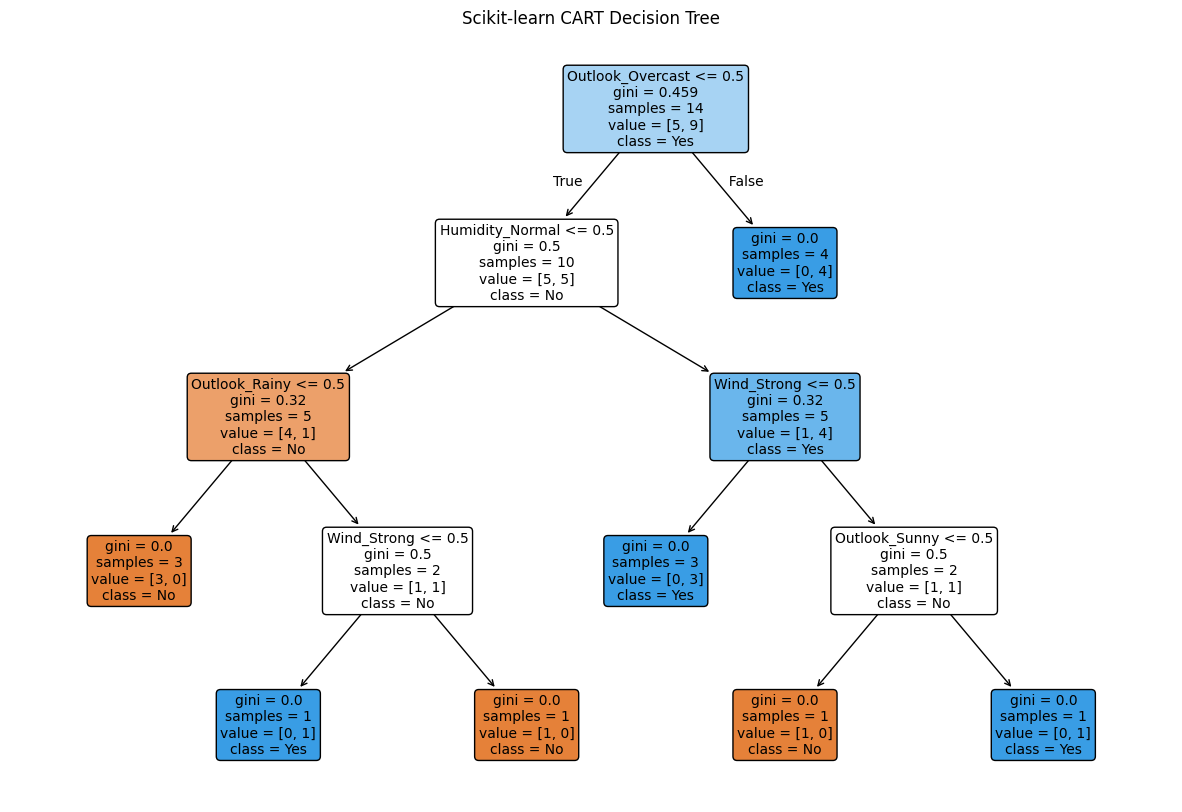


  Prediction on Training Data (CART)
CART Training Accuracy: 100.0%

  Prediction on Test Cases (CART)
 Outlook Temperature Humidity   Wind Predicted (CART)
   Sunny         Hot     High   Weak               No
   Rainy        Mild   Normal Strong               No
Overcast        Cool   Normal Strong              Yes


In [ ]:
# -- Cell 8: Scikit-learn CART Decision Tree Implementation and Comparison --------------------------------------

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt

print("\n" + "=" * 60)
print("  Scikit-learn CART Decision Tree")
print("=" * 60)

# 1. Data Preprocessing for Scikit-learn
# Convert categorical features to numerical using One-Hot Encoding
X = df[FEATURES].copy()
y = df[TARGET].copy()

# Apply One-Hot Encoding to features
X_encoded = pd.get_dummies(X, columns=FEATURES, drop_first=False)

# Apply Label Encoding to the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Get feature names after one-hot encoding
feature_names = X_encoded.columns.tolist()

# Get class names from LabelEncoder
class_names = le.classes_.tolist()

print("\n--- Encoded Features (X_encoded) ---")
print(X_encoded.head())
print("\n--- Encoded Target (y_encoded) ---")
print(y_encoded)
print(f"Target class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 2. Train a CART Decision Tree Classifier
# Using Gini impurity as the criterion (CART algorithm's default)
cart_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_tree.fit(X_encoded, y_encoded)

print("\n" + "=" * 60)
print("  CART Decision Tree Training Complete")
print("=" * 60)

# 3. Visualize the CART Tree (Text Representation)
print("\n--- CART Decision Tree Structure (Text) ---")
r = export_text(cart_tree, feature_names=feature_names, class_names=class_names)
print(r)

# Optional: Visualize the CART Tree (Graphical Representation)
plt.figure(figsize=(15, 10))
plot_tree(cart_tree, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=10, impurity=True)
plt.title("Scikit-learn CART Decision Tree")
plt.show()

# 5. Prediction with CART Model
print("\n" + "=" * 60)
print("  Prediction on Training Data (CART)")
print("=" * 60)

y_train_pred_cart = cart_tree.predict(X_encoded)
accuracy_cart_train = (y_train_pred_cart == y_encoded).mean()
print(f"CART Training Accuracy: {accuracy_cart_train*100:.1f}%")

print("\n" + "=" * 60)
print("  Prediction on Test Cases (CART)")
print("=" * 60)

# Prepare test cases for CART prediction
test_cases = [
    {"Outlook": "Sunny",    "Temperature": "Hot",  "Humidity": "High",   "Wind": "Weak"},
    {"Outlook": "Rainy",    "Temperature": "Mild", "Humidity": "Normal", "Wind": "Strong"},
    {"Outlook": "Overcast", "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong"}
]

test_df_cart = pd.DataFrame(test_cases)
# Ensure new test data has the same one-hot encoded columns as training data
test_X_encoded = pd.get_dummies(test_df_cart, columns=FEATURES, drop_first=False)

# Align columns - crucial if test data doesn't have all categories or has extra ones
# Add missing columns to test_X_encoded and fill with 0
missing_cols = set(X_encoded.columns) - set(test_X_encoded.columns)
for c in missing_cols:
    test_X_encoded[c] = 0
# Remove extra columns from test_X_encoded
extra_cols = set(test_X_encoded.columns) - set(X_encoded.columns)
test_X_encoded = test_X_encoded.drop(columns=list(extra_cols))
# Ensure the order of columns is the same
test_X_encoded = test_X_encoded[X_encoded.columns]

# Predict using the CART model
y_test_pred_cart_encoded = cart_tree.predict(test_X_encoded)
y_test_pred_cart = le.inverse_transform(y_test_pred_cart_encoded)

test_df_cart["Predicted (CART)"] = y_test_pred_cart
print(test_df_cart.to_string(index=False))



#สรุปผลการทดลอง

# ในการทดลองนี้ เราได้สร้าง ID3 Decision Tree จาก dataset ขนาด 14 แถวเพื่อทำนาย target class “Yes” หรือ “No” โดยเริ่มจากคำนวณ entropy ของ dataset ทั้งหมด จากนั้นประเมิน Information Gain ของแต่ละ attribute เพื่อเลือก attribute ที่สามารถแยก class ได้ดีที่สุด ซึ่ง attribute ที่ Gain สูงสุดจะถูกใช้เป็น root node ของ tree และ tree จะถูกสร้างแบบ recursive โดยแต่ละ node จะเลือก attribute ที่ Gain สูงสุดของ subset นั้น ๆ การ split จะดำเนินต่อจนกว่าจะถึง stop condition ได้แก่ ทุก instance ใน subset เป็น class เดียวกัน, ไม่มี attribute เหลือให้ split, หรือ subset ว่าง ในกรณีเหล่านี้จะสร้าง leaf node โดยใช้ class ของ subset หรือ majority class ของ parent node ทำให้ tree สามารถแทนการตัดสินใจของ dataset ได้ครบถ้วนและเข้าใจง่าย ผลการทดลองแสดงให้เห็นว่า ID3 สามารถเลือก attribute ที่สำคัญที่สุดในการตัดสินใจและสร้าง tree ที่ชัดเจน แสดงความสัมพันธ์ระหว่าง attribute และ class ได้อย่างเป็นระบบ